# pyCAFE vs FEniCSx — 20 Acoustic Modes
**Cavity:** 1 m x 0.5 m, air (c0 = 343 m/s). All hard walls (Neumann).  
**Mesh criterion:** 6 CQUAD8 elements per wavelength at the 20th mode frequency.  
**Element:** CQUAD8 serendipity Q2 in both solvers — same DOF count.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import time, math, os, sys

sys.path.insert(0, os.path.abspath("../.."))

Lx, Ly = 1.0, 0.5
c0, rho = 343.0, 1.204
NUM_MODES = 20
ELEMS_PER_LAMBDA = 6

def analytical_modes(Lx, Ly, c0, n_modes):
    modes = []
    for m in range(25):
        for n in range(25):
            if m == 0 and n == 0:
                continue
            f = (c0 / 2) * np.sqrt((m / Lx)**2 + (n / Ly)**2)
            modes.append((f, m, n))
    modes.sort()
    return modes[:n_modes]

modes_ref = analytical_modes(Lx, Ly, c0, NUM_MODES)
f_ref = np.array([f for f, m, n in modes_ref])
f_max = f_ref[-1]

lam_min = c0 / f_max
h_elem  = lam_min / ELEMS_PER_LAMBDA
Nx = math.ceil(Lx / h_elem)
Ny = math.ceil(Ly / h_elem)

# DOF count for CQUAD8 serendipity
dof_ser = (2*Nx+1)*(Ny+1) + Ny*(Nx+1)

print(f"20th mode  : {f_max:.2f} Hz")
print(f"lambda_min : {lam_min:.4f} m")
print(f"h_elem     : {h_elem:.4f} m")
print(f"Grid       : {Nx} x {Ny} elements")
print(f"DOF (CQUAD8 serendipity): {dof_ser}")
print()
print(f"{'#':>3}  {'(m,n)':>7}  {'f [Hz]':>10}")
print("-" * 26)
for i, (f, m, n) in enumerate(modes_ref):
    print(f"{i+1:>3}  ({m},{n}){' ':>3}  {f:>10.3f}")

20th mode  : 1084.66 Hz
lambda_min : 0.3162 m
h_elem     : 0.0527 m
Grid       : 19 x 10 elements
DOF (CQUAD8 serendipity): 629

  #    (m,n)      f [Hz]
--------------------------
  1  (1,0)        171.500
  2  (0,1)        343.000
  3  (2,0)        343.000
  4  (1,1)        383.486
  5  (2,1)        485.075
  6  (3,0)        514.500
  7  (3,1)        618.352
  8  (0,2)        686.000
  9  (4,0)        686.000
 10  (1,2)        707.113
 11  (2,2)        766.971
 12  (4,1)        766.971
 13  (3,2)        857.500
 14  (5,0)        857.500
 15  (5,1)        923.556
 16  (4,2)        970.151
 17  (0,3)       1029.000
 18  (6,0)       1029.000
 19  (1,3)       1043.194
 20  (2,3)       1084.661


In [2]:
import gmsh

MSH_FILE = "comparison_20modes.msh"

if gmsh.isInitialized():
    gmsh.finalize()

gmsh.initialize()
gmsh.model.add("rect")
gmsh.option.setNumber("General.Verbosity", 0)

p1 = gmsh.model.geo.addPoint(0,  0,  0)
p2 = gmsh.model.geo.addPoint(Lx, 0,  0)
p3 = gmsh.model.geo.addPoint(Lx, Ly, 0)
p4 = gmsh.model.geo.addPoint(0,  Ly, 0)
l1 = gmsh.model.geo.addLine(p1, p2)
l2 = gmsh.model.geo.addLine(p2, p3)
l3 = gmsh.model.geo.addLine(p3, p4)
l4 = gmsh.model.geo.addLine(p4, p1)
cl   = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
surf = gmsh.model.geo.addPlaneSurface([cl])

gmsh.model.addPhysicalGroup(1, [l1], name="bottom")
gmsh.model.addPhysicalGroup(1, [l2], name="right")
gmsh.model.addPhysicalGroup(1, [l3], name="top")
gmsh.model.addPhysicalGroup(1, [l4], name="left")
gmsh.model.addPhysicalGroup(2, [surf], name="domain")
gmsh.model.geo.synchronize()

# Structured transfinite quad mesh
gmsh.model.mesh.setTransfiniteCurve(l1, Nx + 1)
gmsh.model.mesh.setTransfiniteCurve(l3, Nx + 1)
gmsh.model.mesh.setTransfiniteCurve(l2, Ny + 1)
gmsh.model.mesh.setTransfiniteCurve(l4, Ny + 1)
gmsh.model.mesh.setTransfiniteSurface(surf)
gmsh.model.mesh.recombine()

gmsh.option.setNumber("Mesh.ElementOrder",         2)
gmsh.option.setNumber("Mesh.RecombineAll",          1)
gmsh.option.setNumber("Mesh.SecondOrderIncomplete", 1)  # serendipity (no interior node) = CQUAD8

gmsh.model.mesh.generate(2)
gmsh.write(MSH_FILE)
gmsh.finalize()

print(f"Mesh written: {MSH_FILE}  ({Nx}x{Ny} CQUAD8 elements)")

Mesh written: comparison_20modes.msh  (19x10 CQUAD8 elements)


Info    : Reading 'comparison_20modes.msh'...
Info    : 9 entities
Info    : 629 nodes
Info    : 248 elements
Info    : Done reading 'comparison_20modes.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 58
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 190

Available boundary names in the mesh:
-------------------------------------
- bottom               | 37 nodes
- right                | 19 nodes
- top                  | 37 nodes
- left                 | 19 nodes


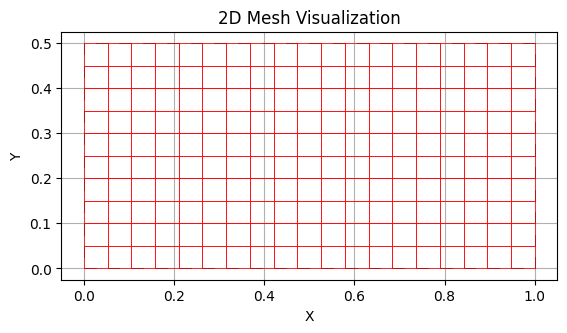

Detected acoustic element type: CQUAD8
pyCAFE  | DOF: 629
        | Assemble: 153.1 ms  Solve: 9.9 ms  Total: 163.0 ms


In [3]:
import pycafe
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced

t0 = time.perf_counter()
fluid  = pycafe.load_fluid("air")
nodes, elements, boundaries = pycafe.load_mesh(MSH_FILE)
bc = ([], [], 0.0, [], 0.0+0j, [], 0.0, None, 0.0)
system = pycafe.prepare_acoustic_system(
    nodes=nodes, elements=elements, boundaries=boundaries,
    rho=fluid["rho"], c0=fluid["c0"], bc=bc, debug=False,
)
t_asm_cafe = time.perf_counter() - t0

t1 = time.perf_counter()
freqs_cafe, _ = solve_modal_acoustic_reduced(
    system["K_red"], system["M_red"], num_modes=NUM_MODES
)
t_sol_cafe  = time.perf_counter() - t1
t_tot_cafe  = time.perf_counter() - t0

n_dof_cafe = system["K_red"].shape[0]
print(f"pyCAFE  | DOF: {n_dof_cafe}")
print(f"        | Assemble: {t_asm_cafe*1e3:.1f} ms  Solve: {t_sol_cafe*1e3:.1f} ms  Total: {t_tot_cafe*1e3:.1f} ms")

In [4]:
from mpi4py import MPI
from dolfinx import mesh as dmesh, fem
from dolfinx.fem import functionspace
from dolfinx.fem.petsc import assemble_matrix as petsc_assemble_matrix
import ufl
from slepc4py import SLEPc

t0 = time.perf_counter()

msh = dmesh.create_rectangle(
    MPI.COMM_WORLD, [[0.0, 0.0], [Lx, Ly]], [Nx, Ny],
    cell_type=dmesh.CellType.quadrilateral,
)

# Serendipity Q2 = same 8-node element as CQUAD8
try:
    V = functionspace(msh, ("Serendipity", 2))
    elem_label = "Serendipity Q2 (8-node)"
except Exception:
    V = functionspace(msh, ("Lagrange", 2))
    elem_label = "Lagrange Q2 (9-node, fallback)"

u, v = ufl.TrialFunction(V), ufl.TestFunction(V)
K_mat = petsc_assemble_matrix(fem.form(ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx))
K_mat.assemble()
M_mat = petsc_assemble_matrix(fem.form((1.0/c0**2) * ufl.inner(u, v) * ufl.dx))
M_mat.assemble()
t_asm_fenics = time.perf_counter() - t0

n_dof_fenics = V.dofmap.index_map.size_global

t1 = time.perf_counter()
eps = SLEPc.EPS().create(MPI.COMM_WORLD)
eps.setOperators(K_mat, M_mat)
eps.setProblemType(SLEPc.EPS.ProblemType.GHEP)
eps.setWhichEigenpairs(SLEPc.EPS.Which.SMALLEST_REAL)
eps.setDimensions(nev=NUM_MODES + 5)
eps.setFromOptions()
eps.solve()

xr, xi_v = K_mat.createVecs()
freqs_fenics = []
for i in range(eps.getConverged()):
    lam = float(np.real(eps.getEigenpair(i, xr, xi_v)))
    if lam > 1000.0:
        freqs_fenics.append(np.sqrt(lam) / (2 * np.pi))
    if len(freqs_fenics) == NUM_MODES:
        break
freqs_fenics = np.array(freqs_fenics)

t_sol_fenics = time.perf_counter() - t1
t_tot_fenics = time.perf_counter() - t0

print(f"FEniCSx | DOF: {n_dof_fenics}  ({elem_label})")
print(f"        | Assemble: {t_asm_fenics*1e3:.1f} ms  Solve: {t_sol_fenics*1e3:.1f} ms  Total: {t_tot_fenics*1e3:.1f} ms")

ld: warning: duplicate -rpath '/opt/miniconda3/envs/pycafe1/lib' ignored
ld: warning: duplicate -rpath '/opt/miniconda3/envs/pycafe1/lib' ignored


ld: warning: duplicate -rpath '/opt/miniconda3/envs/pycafe1/lib' ignored
ld: warning: duplicate -rpath '/opt/miniconda3/envs/pycafe1/lib' ignored


FEniCSx | DOF: 629  (Serendipity Q2 (8-node))
        | Assemble: 1144.6 ms  Solve: 29.4 ms  Total: 1174.0 ms


In [5]:
err_cafe   = np.abs(freqs_cafe   - f_ref) / f_ref * 100
err_fenics = np.abs(freqs_fenics - f_ref) / f_ref * 100

hdr = f"{'#':>3}  {'(m,n)':>7}  {'Analytic':>10}  {'pyCAFE':>10}  {'err%':>9}  {'FEniCSx':>10}  {'err%':>9}"
print("=" * len(hdr))
print(hdr)
print("-" * len(hdr))
for i, (f_an, m, n) in enumerate(modes_ref):
    print(f"{i+1:>3}  ({m},{n}){' ':>3}  {f_an:>10.3f}  {freqs_cafe[i]:>10.3f}  {err_cafe[i]:>8.5f}%  {freqs_fenics[i]:>10.3f}  {err_fenics[i]:>8.5f}%")
print("=" * len(hdr))
print(f"\nMax error  ->  pyCAFE: {err_cafe.max():.5f}%   FEniCSx: {err_fenics.max():.5f}%")
print(f"Mean error ->  pyCAFE: {err_cafe.mean():.6f}%   FEniCSx: {err_fenics.mean():.6f}%")
print(f"DOF        ->  pyCAFE: {n_dof_cafe}   FEniCSx: {n_dof_fenics}")
print(f"Time total ->  pyCAFE: {t_tot_cafe*1e3:.0f} ms   FEniCSx: {t_tot_fenics*1e3:.0f} ms")

  #    (m,n)    Analytic      pyCAFE       err%     FEniCSx       err%
----------------------------------------------------------------------
  1  (1,0)        171.500     171.500   0.00005%     171.500   0.00005%
  2  (0,1)        343.000     343.002   0.00067%     343.002   0.00067%
  3  (2,0)        343.000     343.003   0.00083%     343.003   0.00083%
  4  (1,1)        383.486     383.488   0.00055%     383.488   0.00055%
  5  (2,1)        485.075     485.079   0.00076%     485.079   0.00076%
  6  (3,0)        514.500     514.521   0.00415%     514.521   0.00415%
  7  (3,1)        618.352     618.371   0.00310%     618.371   0.00310%
  8  (0,2)        686.000     686.073   0.01061%     686.073   0.01061%
  9  (4,0)        686.000     686.089   0.01299%     686.089   0.01299%
 10  (1,2)        707.113     707.183   0.00999%     707.183   0.00999%
 11  (2,2)        766.971     767.038   0.00869%     767.038   0.00869%
 12  (4,1)        766.971     767.052   0.01057%     767.052   0.0

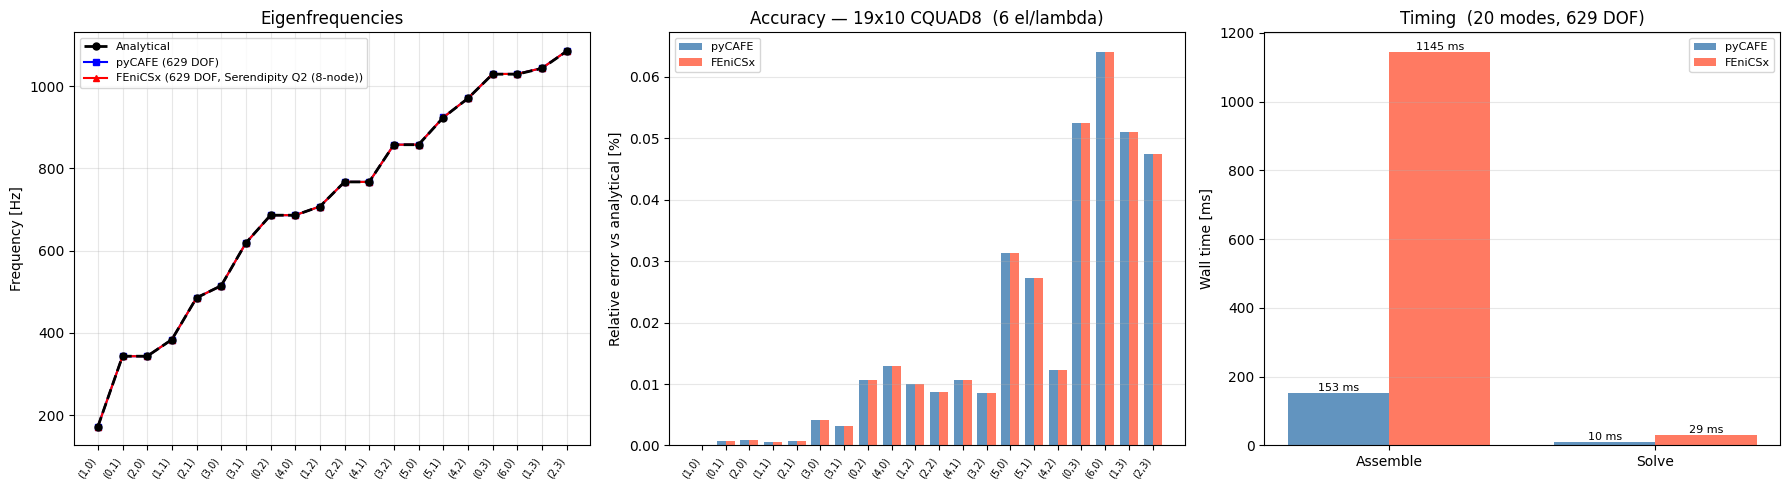

Figure saved -> comparison_20modes.png


In [6]:
mode_labels = [f"({m},{n})" for _, m, n in modes_ref]
x = np.arange(NUM_MODES)
w = 0.38

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 – frequencies
ax = axes[0]
ax.plot(x, f_ref,        "k--o", lw=2,   ms=5, label="Analytical",    zorder=3)
ax.plot(x, freqs_cafe,   "b-s",  lw=1.5, ms=5, label=f"pyCAFE ({n_dof_cafe} DOF)")
ax.plot(x, freqs_fenics, "r-^",  lw=1.5, ms=5, label=f"FEniCSx ({n_dof_fenics} DOF, {elem_label})")
ax.set_xticks(x); ax.set_xticklabels(mode_labels, rotation=55, ha="right", fontsize=7)
ax.set_ylabel("Frequency [Hz]"); ax.set_title("Eigenfrequencies")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 2 – error %
ax2 = axes[1]
ax2.bar(x - w/2, err_cafe,   w, label="pyCAFE",  color="steelblue", alpha=0.85)
ax2.bar(x + w/2, err_fenics, w, label="FEniCSx", color="tomato",    alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(mode_labels, rotation=55, ha="right", fontsize=7)
ax2.set_ylabel("Relative error vs analytical [%]")
ax2.set_title(f"Accuracy — {Nx}x{Ny} CQUAD8  ({ELEMS_PER_LAMBDA} el/lambda)")
ax2.legend(fontsize=8); ax2.grid(True, axis="y", alpha=0.3)

# 3 – timing
ax3 = axes[2]
labs = ["Assemble", "Solve"]
vc = [t_asm_cafe*1e3,   t_sol_cafe*1e3]
vf = [t_asm_fenics*1e3, t_sol_fenics*1e3]
xb = np.arange(2)
b1 = ax3.bar(xb - w/2, vc, w, label="pyCAFE",  color="steelblue", alpha=0.85)
b2 = ax3.bar(xb + w/2, vf, w, label="FEniCSx", color="tomato",    alpha=0.85)
for bar in list(b1) + list(b2):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.0f} ms", ha="center", va="bottom", fontsize=8)
ax3.set_xticks(xb); ax3.set_xticklabels(labs)
ax3.set_ylabel("Wall time [ms]")
ax3.set_title(f"Timing  ({NUM_MODES} modes, {n_dof_cafe} DOF)")
ax3.legend(fontsize=8); ax3.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_20modes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> comparison_20modes.png")